# 03_SVM_Without_DR

## Baseline SVM (Without Dimensionality Reduction)

This notebook trains an SVM baseline on the original feature space. Since SVM is sensitive to scale, it uses a `Pipeline` with `StandardScaler` so scaling is fit only on training data and then applied to test data.


In [2]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

sns.set_style("whitegrid")
ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results directory is ready.")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


Results directory is ready.


### Load Original Train/Test Data

In [3]:
x_train_path = ROOT / "train" / "X_train.csv"
x_test_path = ROOT / "test" / "X_test.csv"

if not x_train_path.exists():
    x_train_path = ROOT / "train" / "x_train.csv"
if not x_test_path.exists():
    x_test_path = ROOT / "test" / "x_test.csv"

y_train_path = ROOT / "train" / "y_train.csv"
y_test_path = ROOT / "test" / "y_test.csv"

X_train = pd.read_csv(x_train_path)
X_test = pd.read_csv(x_test_path)
y_train = pd.read_csv(y_train_path).squeeze()
y_test = pd.read_csv(y_test_path).squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (4930, 30)
X_test: (2113, 30)
y_train: (4930,)
y_test: (2113,)


### Train Baseline SVM Pipeline

Why scaling is required:
- SVM relies on distances and margins.
- Features on larger numeric ranges can dominate the optimization if not scaled.
- `StandardScaler` in a pipeline prevents leakage by fitting only on training data.


In [4]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", random_state=42)),
])

svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)


In [5]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
}
metrics_df = pd.DataFrame([metrics])
metrics_path = RESULTS_DIR / "svm_without_dr_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("SVM Without DR metrics:")
print(metrics_df.to_string(index=False))
print("\nSaved metrics CSV to results/.")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

comparison_script = ROOT / "scripts" / "update_model_comparison.py"
if comparison_script.exists():
    subprocess.run(["python", str(comparison_script)], check=False)
    print("Updated model_comparison_results.csv")


SVM Without DR metrics:
 Accuracy  Precision   Recall  F1-score
 0.794132   0.647887 0.491979  0.559271

Saved metrics CSV to results/.

Confusion Matrix:
[[1402  150]
 [ 285  276]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1552
           1       0.65      0.49      0.56       561

    accuracy                           0.79      2113
   macro avg       0.74      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



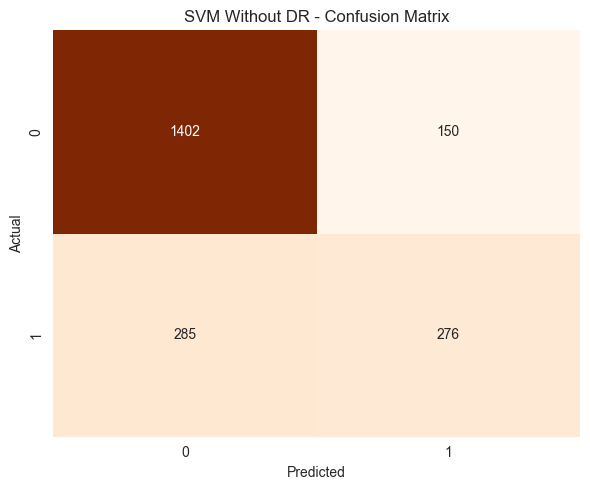

Saved confusion matrix plot to results/.


In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.title("SVM Without DR - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
cm_path = RESULTS_DIR / "svm_without_dr_confusion_matrix.png"
plt.tight_layout()
plt.savefig(cm_path, dpi=300)
plt.show()
print("Saved confusion matrix plot to results/.")


In [7]:
print("\nExperiment completed successfully.")
print("Results (metrics CSV and confusion matrix plot) were saved in the results/ directory.")
print("Use Accuracy, Precision, Recall, and F1-score together for balanced model evaluation.")



Experiment completed successfully.
Results (metrics CSV and confusion matrix plot) were saved in the results/ directory.
Use Accuracy, Precision, Recall, and F1-score together for balanced model evaluation.
